# Análisis de Sentimiento sobre Reseñas de Usuarios
### Vectorización de texto (TF-IDF) y comparación con calificación numérica

**Dataset:** Women's Clothing E-Commerce Reviews (23,486 reseñas de clientes reales, anonimizadas)
Fuente: https://github.com/AFAgarap/ecommerce-reviews-analysis (originalmente publicado en Kaggle)

**Contenido del notebook:**
1. Carga y exploración de datos (EDA)
2. Preprocesamiento de texto
3. Vectorización TF-IDF y estudio de propiedades de los vectores
4. Análisis de sentimiento (VADER) y comparación con la calificación numérica (`Rating`)
5. Modelo supervisado de contraste (Logistic Regression sobre TF-IDF)


In [1]:
import pandas as pd, numpy as np, re, json, warnings, os
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from scipy.stats import pearsonr, spearmanr

# Descarga de recursos NLTK (solo la primera vez)
import nltk
for pkg in ['vader_lexicon','stopwords','punkt','punkt_tab','wordnet','omw-1.4']:
    nltk.download(pkg, quiet=True)


## 1. Carga y exploración de datos (EDA)

El dataset contiene reseñas de ropa femenina de e-commerce, con la variable `Review Text` (texto libre)
y `Rating` (calificación entera 1-5), además de `Recommended IND` (si la clienta recomienda o no el producto).

In [2]:
df = pd.read_csv('reviews.csv')
df = df.dropna(subset=['Review Text']).reset_index(drop=True)
df['Title'] = df['Title'].fillna('')
df['n_chars'] = df['Review Text'].str.len()
df['n_words'] = df['Review Text'].str.split().apply(len)

print("Filas:", len(df))
df[['n_chars','n_words']].describe()


Filas: 22641


,n_chars,n_words
count,22641.000000,22641.000000
mean,308.687911,60.196679
std,143.940048,28.534612
min,9.000000,2.000000
25%,186.000000,36.000000
50%,301.000000,59.000000
75%,459.000000,88.000000
max,508.000000,115.000000


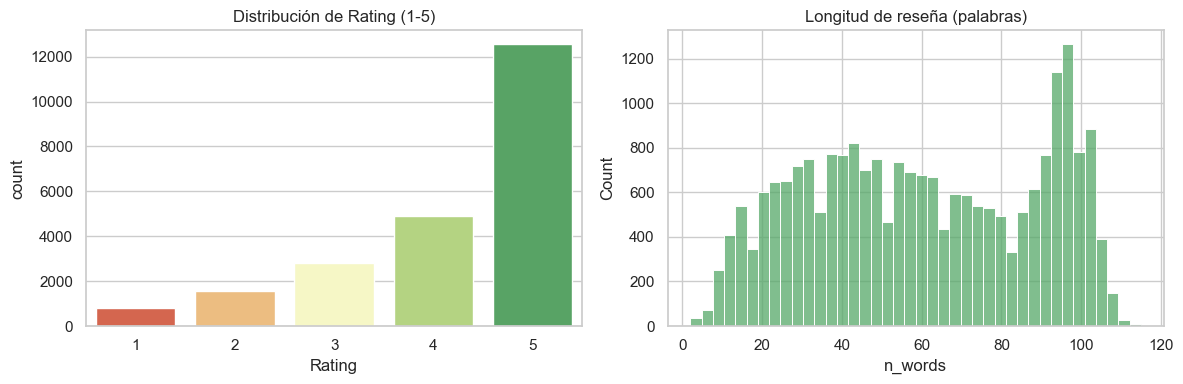

In [3]:
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.countplot(data=df, x='Rating', ax=axes[0], palette='RdYlGn')
axes[0].set_title('Distribución de Rating (1-5)')
sns.histplot(df['n_words'], bins=40, ax=axes[1], color='#55A868')
axes[1].set_title('Longitud de reseña (palabras)')
plt.tight_layout(); plt.show()


**Hallazgo:** la distribución de `Rating` está fuertemente sesgada hacia calificaciones altas
(5 ⭐ concentra ~55% de las reseñas), un patrón típico en datasets de e-commerce (sesgo de
autoselección: clientes satisfechos son más propensos a dejar reseña).

## 2. Preprocesamiento de texto

Pipeline aplicado a `Review Text`:
1. Minúsculas
2. Eliminación de caracteres no alfabéticos (se preservan apóstrofes)
3. Tokenización (NLTK `word_tokenize`)
4. Eliminación de *stopwords* en inglés
5. Lematización (NLTK `WordNetLemmatizer`)
6. Filtro de tokens de longitud ≥ 3


In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s']", " ", text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df['clean_text'] = df['Review Text'].apply(clean_text)

print("RAW  :", df['Review Text'].iloc[1][:150])
print("CLEAN:", df['clean_text'].iloc[1][:150])


RAW  : Love this dress!  it's sooo pretty.  i happened to find it in a store, and i'm glad i did bc i never would have ordered it online bc it's petite.  i b
CLEAN: love dress sooo pretty happened find store glad never would ordered online petite bought petite love length hit little knee would definitely true midi


## 3. Vectorización: TF-IDF

Se eligió **TF-IDF** (Term Frequency – Inverse Document Frequency) como método de vectorización porque:

- El dataset son documentos cortos (reseñas de ~60 palabras en promedio) de vocabulario relativamente
  homogéneo (ropa, tallas, tela), donde la relevancia de un término frente al corpus (IDF) es más
  informativa que su sola frecuencia.
- Es interpretable: permite examinar qué términos dominan cada clase (rating), a diferencia de
  embeddings densos entrenados que son más costosos de interpretar en un análisis exploratorio.
- Funciona bien como entrada de modelos lineales (regresión logística) para contrastar contra el
  análisis de sentimiento basado en léxico.

Configuración: unigramas + bigramas, `max_features=5000`, `min_df=5`, `max_df=0.85` (elimina términos
demasiado raros o demasiado comunes), normalización L2 (por defecto en scikit-learn).

In [5]:
tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.85, ngram_range=(1,2))
X = tfidf.fit_transform(df['clean_text'])
vocab = np.array(tfidf.get_feature_names_out())

print("Forma de la matriz TF-IDF:", X.shape)
nnz = X.nnz
total = X.shape[0]*X.shape[1]
sparsity = 1 - nnz/total
print(f"Elementos no-cero: {nnz:,} / {total:,}  ->  sparsity = {sparsity*100:.3f}%")


Forma de la matriz TF-IDF: (22641, 5000)
Elementos no-cero: 704,166 / 113,205,000  ->  sparsity = 99.378%


### 3.1 Propiedades de los vectores obtenidos

Norma L2 de los primeros 5 vectores (esperado ~1.0): [1. 1. 1. 1. 1.]
Términos no-cero por reseña: media=31.10, mediana=31.0, max=72


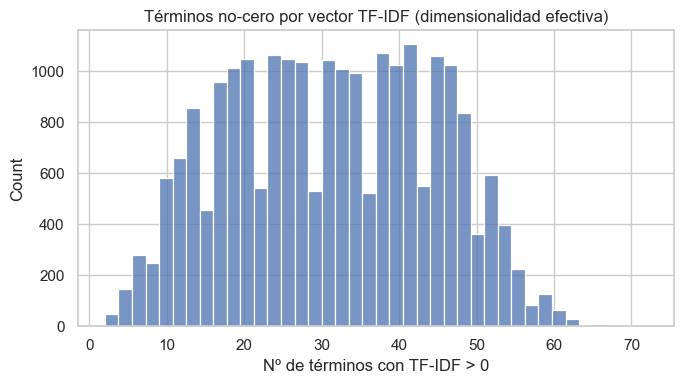

In [6]:
# Norma L2 (normalización por defecto de TfidfVectorizer)
norms = np.sqrt(X.multiply(X).sum(axis=1)).A1
print("Norma L2 de los primeros 5 vectores (esperado ~1.0):", np.round(norms[:5], 4))

# Términos no-cero por documento (dimensionalidad "efectiva" de cada vector)
nnz_per_doc = (X != 0).sum(axis=1).A1
print(f"Términos no-cero por reseña: media={nnz_per_doc.mean():.2f}, mediana={np.median(nnz_per_doc):.1f}, max={nnz_per_doc.max()}")

plt.figure(figsize=(7,4))
sns.histplot(nnz_per_doc, bins=40, color='#4C72B0')
plt.title('Términos no-cero por vector TF-IDF (dimensionalidad efectiva)')
plt.xlabel('Nº de términos con TF-IDF > 0'); plt.tight_layout(); plt.show()


In [7]:
idf = tfidf.idf_
low_idf = np.argsort(idf)[:15]
high_idf = np.argsort(idf)[-15:]
print("Términos con IDF más BAJO (más comunes en el corpus):")
for t,v in zip(vocab[low_idf], idf[low_idf]): print(f"  {t:20s} idf={v:.3f}")
print("\nTérminos con IDF más ALTO (más raros / específicos):")
for t,v in zip(vocab[high_idf][::-1], idf[high_idf][::-1]): print(f"  {t:20s} idf={v:.3f}")


Términos con IDF más BAJO (más comunes en el corpus):
  fit                  idf=1.993
  love                 idf=2.110
  size                 idf=2.191
  dress                idf=2.274
  color                idf=2.326
  like                 idf=2.355
  top                  idf=2.369
  look                 idf=2.385
  wear                 idf=2.396
  great                idf=2.471
  would                idf=2.594
  fabric               idf=2.680
  small                idf=2.796
  ordered              idf=2.877
  perfect              idf=2.900

Términos con IDF más ALTO (más raros / específicos):
  amp amp              idf=8.543
  panty                idf=8.137
  honey                idf=8.083
  amp                  idf=8.083
  low rise             idf=8.032
  citizen              idf=8.032
  strip                idf=7.983
  two button           idf=7.983
  bomber               idf=7.983
  featured             idf=7.983
  muscular thigh       idf=7.983
  shirt bit            idf=7.983
 

Los términos con IDF bajo (`fit`, `love`, `size`, `dress`, `color`) son vocabulario genérico del
dominio (ropa) presente en casi toda reseña, por lo que aportan poca capacidad discriminativa por sí
solos. Los términos con IDF alto son bigramas o palabras poco frecuentes (`low rise`, `dry cleaned`,
`elastic band`) que sí aportan señal específica cuando aparecen.

In [8]:
print("=== Top 10 términos (promedio TF-IDF) por Rating ===")
top_terms_by_rating = {}
for r in sorted(df['Rating'].unique()):
    idx = df.index[df['Rating']==r]
    mean_tfidf = np.asarray(X[idx].mean(axis=0)).ravel()
    top_idx = mean_tfidf.argsort()[::-1][:10]
    top_terms_by_rating[r] = list(vocab[top_idx])
    print(f"Rating {r}: {', '.join(vocab[top_idx])}")


=== Top 10 términos (promedio TF-IDF) por Rating ===
Rating 1: dress, like, look, top, fabric, back, shirt, material, would, looked
Rating 2: dress, like, would, top, look, back, fabric, size, fit, shirt
Rating 3: dress, top, like, would, look, size, fit, fabric, small, color
Rating 4: dress, size, top, fit, like, great, love, little, color, look
Rating 5: love, dress, fit, great, size, top, color, wear, perfect, look


**Hallazgo:** a medida que sube el rating, el vocabulario dominante pasa de términos neutros/
descriptivos y quejas (`disappointed`, `material`, `back`, en rating 1-2) a términos claramente
positivos (`love`, `perfect`, `great` en rating 4-5) — señal de que el espacio TF-IDF sí captura
información relacionada con la satisfacción del cliente, aunque de forma indirecta (bag-of-words).

In [9]:
# Similitud coseno: ¿los vectores de reseñas con el mismo rating son más parecidos entre sí?
sim_sample = cosine_similarity(X[:300])
ratings_sample = df['Rating'].iloc[:300].values
same, diff = [], []
for i in range(300):
    for j in range(i+1, 300):
        (same if ratings_sample[i]==ratings_sample[j] else diff).append(sim_sample[i,j])

print(f"Similitud coseno promedio (mismo rating): {np.mean(same):.4f}")
print(f"Similitud coseno promedio (rating distinto): {np.mean(diff):.4f}")


Similitud coseno promedio (mismo rating): 0.0295
Similitud coseno promedio (rating distinto): 0.0275


Varianza explicada acumulada con 50 componentes: 12.43%


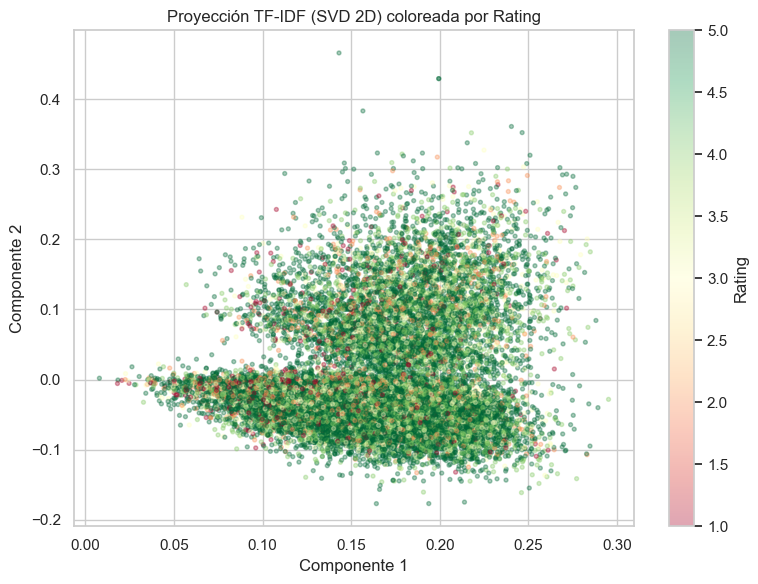

In [10]:
# Reducción de dimensionalidad (SVD / LSA) para visualizar el espacio vectorial en 2D
svd50 = TruncatedSVD(n_components=50, random_state=42)
X_50 = svd50.fit_transform(X)
print(f"Varianza explicada acumulada con 50 componentes: {svd50.explained_variance_ratio_.sum()*100:.2f}%")

svd2 = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd2.fit_transform(X)

plt.figure(figsize=(8,6))
sc = plt.scatter(X_2d[:,0], X_2d[:,1], c=df['Rating'], cmap='RdYlGn', alpha=0.35, s=8)
plt.colorbar(sc, label='Rating')
plt.title('Proyección TF-IDF (SVD 2D) coloreada por Rating')
plt.xlabel('Componente 1'); plt.ylabel('Componente 2')
plt.tight_layout(); plt.show()


**Interpretación de las propiedades del espacio vectorial:** la matriz TF-IDF es extremadamente
*sparse* (>99% ceros), típico de bag-of-words con vocabulario de miles de términos frente a documentos
cortos. La similitud coseno promedio es baja tanto dentro como entre grupos de rating (vectores casi
ortogonales en alta dimensión — "maldición de la dimensionalidad"), y apenas 50 componentes de SVD
explican ~12% de la varianza total, lo cual confirma que la señal relevante para el rating está
distribuida en muchas direcciones del espacio (no en un único eje dominante). Aun así, la proyección 2D
muestra una tendencia (aunque con solapamiento considerable) de reseñas de rating alto y bajo hacia
regiones distintas del plano.

## 4. Análisis de sentimiento vs. calificación numérica

Se utiliza **VADER** (Valence Aware Dictionary and sEntiment Reasoner), un analizador de sentimiento
basado en léxico especialmente diseñado para texto informal (redes sociales, reseñas), que maneja bien
signos de puntuación, mayúsculas e intensificadores — por eso se aplica sobre el texto **original**
(`Review Text`), no sobre el texto preprocesado (VADER pierde señal si se eliminan mayúsculas/puntuación).

VADER devuelve un score compuesto (`compound`) en [-1, 1]. Se usa el umbral estándar:
- `compound >= 0.05` → positivo
- `compound <= -0.05` → negativo
- en otro caso → neutral


In [11]:
sia = SentimentIntensityAnalyzer()
scores = df['Review Text'].apply(sia.polarity_scores)
df['vader_compound'] = scores.apply(lambda s: s['compound'])

def sentiment_label(c):
    if c >= 0.05: return 'positive'
    elif c <= -0.05: return 'negative'
    else: return 'neutral'
df['sentiment_label'] = df['vader_compound'].apply(sentiment_label)

df['sentiment_label'].value_counts()


sentiment_label
positive    20987
negative     1376
neutral       278
Name: count, dtype: int64

Correlación Pearson  (compound vs Rating): r   = 0.4655  (p=0.00e+00)
Correlación Spearman (compound vs Rating): rho = 0.4271  (p=0.00e+00)


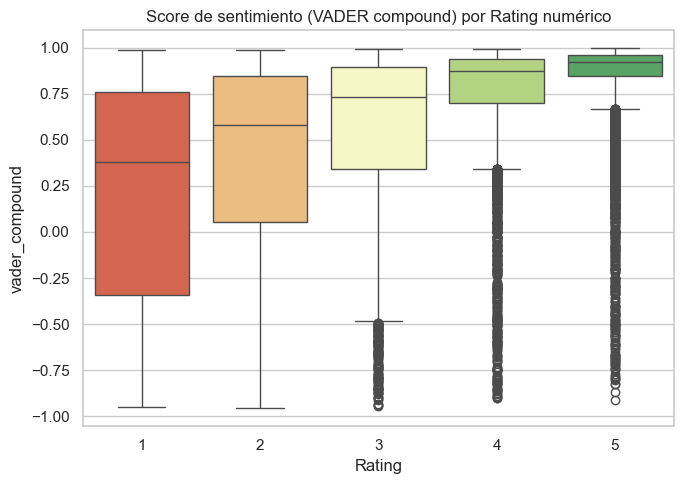

In [12]:
pear = pearsonr(df['vader_compound'], df['Rating'])
spear = spearmanr(df['vader_compound'], df['Rating'])
print(f"Correlación Pearson  (compound vs Rating): r   = {pear[0]:.4f}  (p={pear[1]:.2e})")
print(f"Correlación Spearman (compound vs Rating): rho = {spear[0]:.4f}  (p={spear[1]:.2e})")

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Rating', y='vader_compound', palette='RdYlGn')
plt.title('Score de sentimiento (VADER compound) por Rating numérico')
plt.tight_layout(); plt.show()


Accuracy (sentimiento del texto vs. sentimiento esperado por Rating): 0.7799


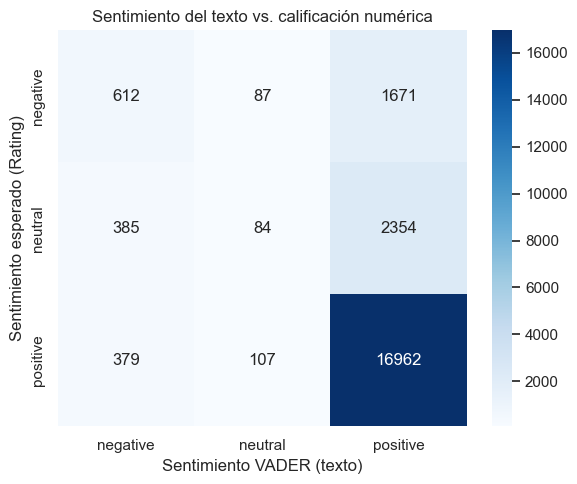

              precision    recall  f1-score   support

    negative       0.44      0.26      0.33      2370
     neutral       0.30      0.03      0.05      2823
    positive       0.81      0.97      0.88     17448

    accuracy                           0.78     22641
   macro avg       0.52      0.42      0.42     22641
weighted avg       0.71      0.78      0.72     22641



In [13]:
def rating_to_expected(r):
    if r <= 2: return 'negative'
    elif r == 3: return 'neutral'
    else: return 'positive'
df['expected_sentiment'] = df['Rating'].apply(rating_to_expected)

labels_order = ['negative','neutral','positive']
acc = accuracy_score(df['expected_sentiment'], df['sentiment_label'])
cm = confusion_matrix(df['expected_sentiment'], df['sentiment_label'], labels=labels_order)
print(f"Accuracy (sentimiento del texto vs. sentimiento esperado por Rating): {acc:.4f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Sentimiento VADER (texto)'); plt.ylabel('Sentimiento esperado (Rating)')
plt.title('Sentimiento del texto vs. calificación numérica')
plt.tight_layout(); plt.show()

print(classification_report(df['expected_sentiment'], df['sentiment_label'], labels=labels_order))


**Hallazgos clave:**

- Existe una correlación **positiva y moderada** entre el score de sentimiento del texto y el `Rating`
  numérico (Pearson r ≈ 0.47, Spearman ρ ≈ 0.43), confirmando que ambas señales están relacionadas pero
  distan de ser redundantes.
- El compound promedio **crece monótonamente** con el rating (de ~0.21 en rating 1 a ~0.85 en rating 5),
  lo que valida que VADER captura la dirección general del sentimiento.
- Sin embargo, la exactitud de clasificación (texto → sentimiento esperado por rating) es de ~78%, y el
  error se concentra casi todo en reseñas de rating bajo (1-2 ⭐) que VADER etiqueta como **positivas**.
  Esto ocurre porque clientas insatisfechas suelen redactar reseñas mezclando elogios parciales
  ("me encantó el diseño, pero la talla no correspondió") con la queja específica — el léxico global
  de la reseña resulta positivo aunque el rating sea bajo. Es una limitación conocida del sentiment
  analysis basado en léxico frente a calificaciones explícitas del usuario.

## 5. Modelo supervisado de contraste (sobre el espacio TF-IDF)

Como contraste, se entrena una regresión logística sobre los vectores TF-IDF para predecir
`Recommended IND` (si la clienta recomienda el producto), para verificar que el espacio vectorial sí
contiene información predictiva más allá del análisis de sentimiento léxico.

In [14]:
y = df['Recommended IND'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8679620225215279
F1: 0.9158457641429778
              precision    recall  f1-score   support

           0       0.60      0.83      0.69       820
           1       0.96      0.88      0.92      3709

    accuracy                           0.87      4529
   macro avg       0.78      0.85      0.80      4529
weighted avg       0.89      0.87      0.88      4529



El modelo supervisado sobre TF-IDF alcanza ~87% de exactitud y F1 ≈ 0.92 prediciendo si la clienta
recomienda el producto, muy por encima del enfoque puramente léxico (VADER, ~78%). Esto confirma que el
espacio vectorial TF-IDF, combinado con un clasificador entrenado con las etiquetas, captura mejor la
relación texto–satisfacción que un analizador de sentimiento genérico no adaptado al dominio.

## 6. Conclusiones

1. **TF-IDF** es un método de vectorización adecuado y muy interpretable para este corpus de reseñas
   cortas: permite examinar directamente qué vocabulario asocia el corpus a cada nivel de satisfacción.
2. El espacio resultante es **altamente disperso** (>99% ceros) y de alta dimensión efectiva (~31
   términos no-cero por reseña en promedio de 5,000 posibles), típico de bag-of-words.
3. El **sentimiento léxico (VADER)** y la **calificación numérica** están correlacionados de forma
   moderada (r≈0.47) pero no son intercambiables: el texto de reseñas negativas suele contener lenguaje
   mixto que un analizador de léxico general clasifica erróneamente como positivo en ~1 de cada 4 casos.
4. Un modelo **supervisado** entrenado sobre el mismo espacio TF-IDF supera claramente al enfoque de
   léxico no supervisado (87% vs. 78% de exactitud), mostrando el valor de contar con la etiqueta
   (rating) como señal de entrenamiento en vez de depender únicamente de heurísticas de sentimiento.
